<h2 align="center">The Most Valuable Skills for Data Engineers (US)</h2>

In [1]:
# importing the libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import ast

# loading the dataset
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

# sorting by date
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])

# converting job_skills from string to list
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])

c:\Users\mrpra\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# we will select Data Engineer as job title and Unites States as country as we have most of the data from US
df_DA_US = df[(df['job_country']=='United States')&(df['job_title_short']=='Data Engineer')].dropna(subset='salary_year_avg').copy()

# exploding the values of job_skills so that we can get associated salary with that
df_DA_US_exploded = df_DA_US.explode('job_skills')

df_DA_US_exploded[['job_skills','salary_year_avg']]

,job_skills,salary_year_avg
92,sql,120000.0
92,python,120000.0
146,golang,129500.0
146,scala,129500.0
146,python,129500.0
...,...,...
785624,alteryx,139216.0
785624,power bi,139216.0
785624,tableau,139216.0
785624,qlik,139216.0


In [3]:
# creating the new dataframe for 1. skill count 2. median salary
df_DA_skills = df_DA_US_exploded.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by='count',ascending=False)

# renaming the columns
df_DA_skills = df_DA_skills.rename(columns={'count':'skill_count','median':'median_salary'})

# now avoiding hard coding we have to find the total job postings of data Engineers job in us
DA_count = len(df_DA_US)    # from calculation we got 4350

# now we will create a new column of corresponding skill present in the job posting 
df_DA_skills['skill_percent'] = df_DA_skills['skill_count']/DA_count*100

#  to avoid erros we will only take skills which have at least 1  mention
df_DA_skills = df_DA_skills[df_DA_skills['skill_count']>0]
df_DA_skills

,skill_count,median_salary,skill_percent
job_skills,,,
sql,2110,125000.00000,72.384220
python,2007,127794.50000,68.850772
aws,1313,131000.00000,45.042882
spark,968,137410.15625,33.207547
azure,961,125000.00000,32.967410
...,...,...,...
vue,1,200000.00000,0.034305
vue.js,1,116250.00000,0.034305
wire,1,90000.00000,0.034305


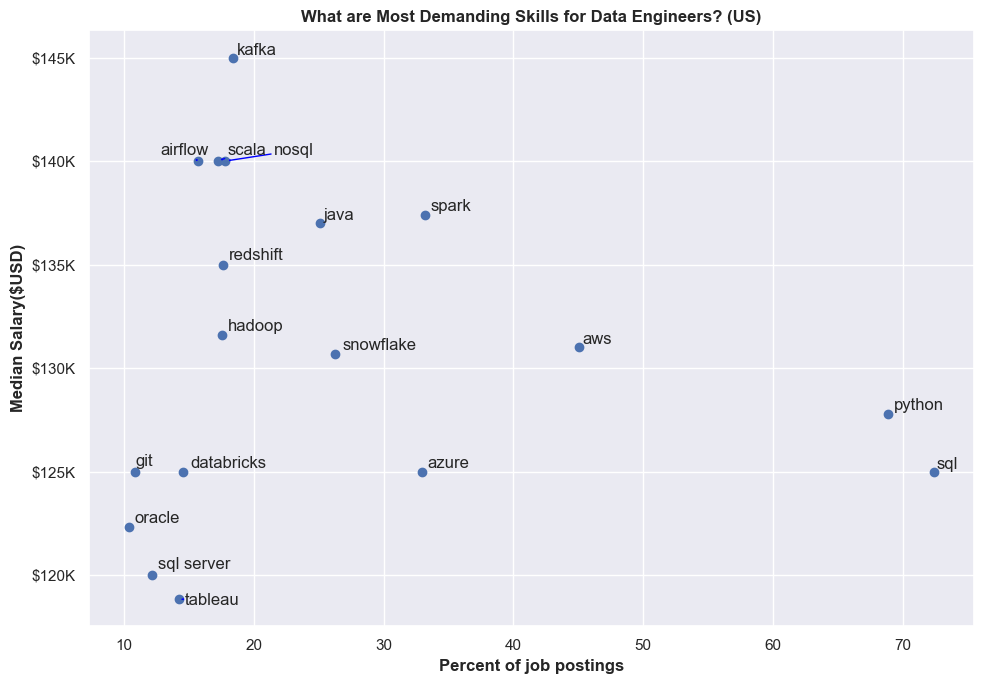

In [11]:
# creating a limit of at least 5% to a certain skill to appear
skill_limit = 10
skill_high_demand = df_DA_skills[df_DA_skills['skill_percent']>skill_limit]

fig, ax = plt.subplots(figsize=(10,7))

from adjustText import adjust_text
from matplotlib.patches import ArrowStyle

# now finally we can plot the scatter plot
plt.scatter(skill_high_demand['skill_percent'],skill_high_demand['median_salary'])

# now getting current axes and formatting it accordingly
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y , pos: f'${int(y/1000)}K'))

# adding the lables
texts = []
for i, txt in enumerate(skill_high_demand.index):
    texts.append(plt.text(skill_high_demand['skill_percent'].iloc[i],skill_high_demand['median_salary'].iloc[i],''+ txt))

# adjusting the arrows
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='blue'))

plt.xlabel('Percent of job postings',fontweight='bold')
plt.ylabel('Median Salary($USD)',fontweight='bold')
plt.title('What are Most Demanding Skills for Data Engineers? (US)',fontweight='bold')
plt.tight_layout()
plt.show()



In [5]:
# now we can also add skill type by technology type and coloring them accordingly

df_technology = df['job_type_skills'].copy()

# remove duplicates
df_technology = df_technology.drop_duplicates()

# remove NaN values
df_technology = df_technology.dropna()

# combine all dictionaries into one
technology_dict = {}
for row in df_technology:
    row_dict = ast.literal_eval(row)  # convert string to dictionary
    for key, value in row_dict.items():
        if key in technology_dict:  # if key already exists in technology_dict, add value to existing value
            technology_dict[key] += value
        else:                       # if key does not exist in technology_dict, add key and value
            technology_dict[key] = value

# remove duplicates by converting values to set then back to list
for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))

In [6]:
technology_dict

{'analyst_tools': ['qlik',
  'sheets',
  'microstrategy',
  'sharepoint',
  'outlook',
  'nuix',
  'powerbi',
  'powerpoint',
  'datarobot',
  'power bi',
  'ms access',
  'sap',
  'visio',
  'spreadsheet',
  'word',
  'sas',
  'splunk',
  'cognos',
  'msaccess',
  'alteryx',
  'esquisse',
  'spss',
  'excel',
  'ssrs',
  'looker',
  'ssis',
  'tableau',
  'dax'],
 'programming': ['delphi',
  'matlab',
  'c#',
  'lua',
  'golang',
  'solidity',
  'c',
  'cobol',
  'javascript',
  'go',
  'assembly',
  'no-sql',
  'clojure',
  'sql',
  'java',
  'c++',
  'powershell',
  'swift',
  'dart',
  'ocaml',
  'shell',
  'f#',
  'apl',
  'bash',
  'rust',
  'mongo',
  'visualbasic',
  'sas',
  'pascal',
  'vb.net',
  'lisp',
  'python',
  't-sql',
  'objective-c',
  'erlang',
  'mongodb',
  'r',
  'css',
  'php',
  'vba',
  'visual basic',
  'julia',
  'kotlin',
  'perl',
  'elixir',
  'fortran',
  'crystal',
  'sass',
  'haskell',
  'groovy',
  'ruby',
  'nosql',
  'html',
  'scala',
  'typescr

In [7]:
# turn dictionary into dataframe
df_technology = pd.DataFrame(list(technology_dict.items()), columns=['technology', 'skills'])

df_technology = df_technology.explode('skills')

df_technology

,technology,skills
0,analyst_tools,qlik
0,analyst_tools,sheets
0,analyst_tools,microstrategy
0,analyst_tools,sharepoint
0,analyst_tools,outlook
...,...,...
9,sync,twilio
9,sync,mattermost
9,sync,google chat
9,sync,ringcentral


In [8]:
# merge df_DA_skills and df_technology
df_DA_skills_tech = df_DA_skills.merge(df_technology, left_on='job_skills', right_on='skills')

df_DA_skills_tech

,skill_count,median_salary,skill_percent,technology,skills
0,2110,125000.00000,72.384220,programming,sql
1,2007,127794.50000,68.850772,programming,python
2,1313,131000.00000,45.042882,cloud,aws
3,968,137410.15625,33.207547,libraries,spark
4,961,125000.00000,32.967410,cloud,azure
...,...,...,...,...,...
178,1,200000.00000,0.034305,webframeworks,vue
179,1,116250.00000,0.034305,webframeworks,vue.js
180,1,90000.00000,0.034305,sync,wire
181,1,117500.00000,0.034305,libraries,xamarin


In [9]:
df_DA_skills_demand = df_DA_skills_tech[df_DA_skills_tech['skill_percent'] > skill_limit]

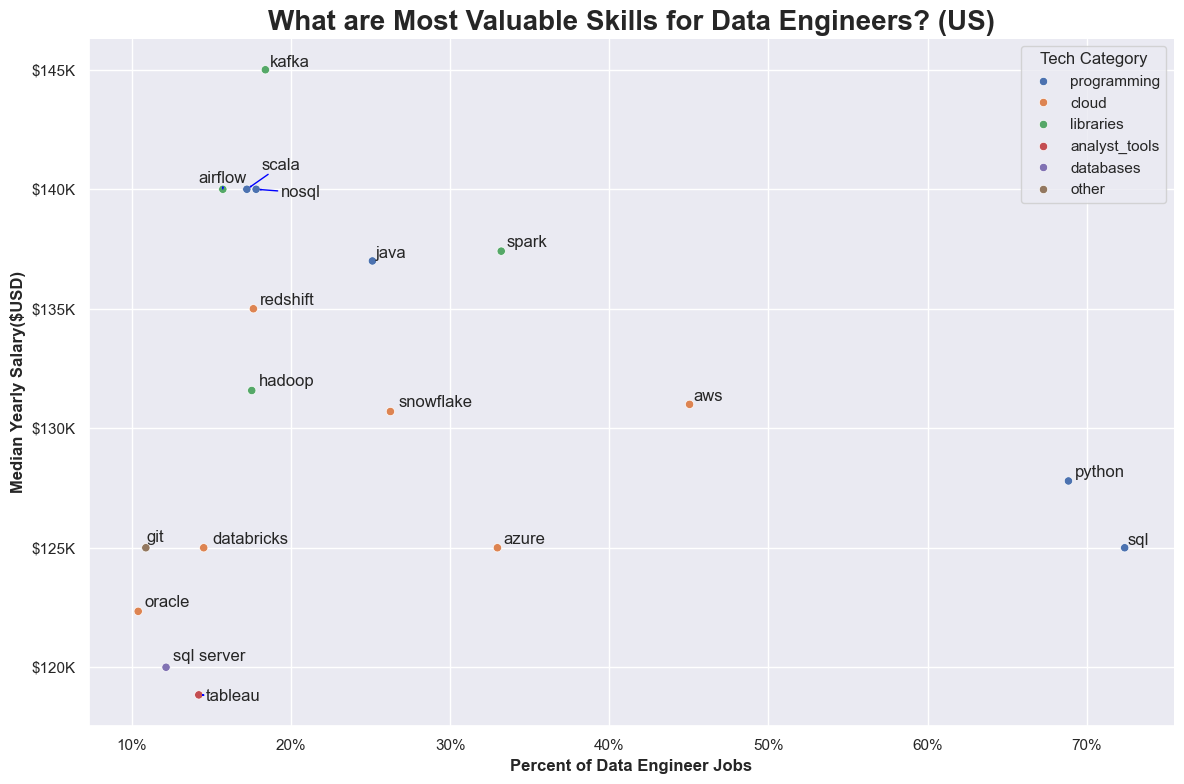

In [12]:
plt.figure(figsize=(12, 8)) 
sns.scatterplot(
    data=df_DA_skills_demand,
    x='skill_percent',
    y='median_salary',
    hue='technology',


)
sns.despine()
sns.set_theme(style='darkgrid',palette='deep')

# Prepare texts for adjustText
texts = []
for i, txt in enumerate(skill_high_demand.index):
    texts.append(plt.text(skill_high_demand['skill_percent'].iloc[i], skill_high_demand['median_salary'].iloc[i], txt))

# Adjust text to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='blue'))

# Set axis labels, title, and legend
plt.xlabel('Percent of Data Engineer Jobs',fontweight='bold')
plt.ylabel('Median Yearly Salary($USD)',fontweight='bold')
plt.title('What are Most Valuable Skills for Data Engineers? (US)',fontweight='bold',fontsize=20)
plt.legend(title='Tech Category')

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))

# Adjust layout and display plot 
plt.tight_layout()
plt.show()